### Imported libraries 

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
from utilities import confirm_env_variable
from utilities import get_params
import os
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torchrl.envs import TransformedEnv, EnvCreator
from tensordict.nn.distributions import NormalParamExtractor
import torch
from torch import nn
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torch.distributions import Categorical

from torchrl.collectors import SyncDataCollector, MultiSyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.objectives.value import GAE
from tqdm import tqdm
# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor
from torchrl.objectives import ClipPPOLoss, ValueEstimators
import matplotlib.pyplot as plt
import torch
from torch.utils.tensorboard import SummaryWriter
from torchrl.envs import ParallelEnv
%load_ext tensorboard

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

DEBUG:tensorflow:Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


### Hyperparameters specification

In [2]:
# Devices
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 32  # Number of team frames collected per training iteration
n_iters = 32  # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 16  # Number of optimization steps per training iteration
minibatch_size = 16  # Size of the mini-batches in each optimization step
lr = 1e-3  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
gamma = 0.9  # discount factor
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

### Environment Creation

In [3]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS], nomachines=True)

INFO:root:[SUCCESS] Generated 4 routes
INFO:root:Simulator is ready to simulate!
INFO:root:Environment initiated!
INFO:root:Free-flow times: {(0, 0): [1.9675870348139257, 2.080892356942777, 2.3193645780846532], (0, 1): [1.1184673869547819, 1.6727891156462587, 0.7787715086034414], (1, 0): [1.2334249322479174, 3.6486022329931425, 4.833881672342676], (1, 1): [3.5679778462861034, 2.0394956830824484, 2.0852624995282487]}
INFO:root:Free flow times calculated!
INFO:root:There are no machines in this environment!
INFO:root:Free-flow times: {(0, 0): [1.9675870348139257, 2.080892356942777, 2.3193645780846532], (0, 1): [1.1184673869547819, 1.6727891156462587, 0.7787715086034414], (1, 0): [1.2334249322479174, 3.6486022329931425, 4.833881672342676], (1, 1): [3.5679778462861034, 2.0394956830824484, 2.0852624995282487]}
INFO:root:[SUCCESS] Created agent objects (200)
INFO:root:Machine's observation space is: {} 
INFO:root:Machine's action space is: {}
INFO:root:Minimum travel time is: 0.7787715086034

## Humans learning for 300 days

In [4]:
env.start()
observations, infos = env.reset()

for ep in range(1, 10):

    env.reset()
    print(f"Episode {ep}\n\n")
    env.step(machine_joint_action=None)

INFO:root:RESET
INFO:root:New sumo label: 1038
INFO:root:RESET
INFO:root:New sumo label: 20
INFO:root:STEP
INFO:root:New sumo label: 5645


Episode 1




INFO:root:RESET
INFO:root:New sumo label: 7830
INFO:root:STEP
INFO:root:New sumo label: 3981


Episode 2




INFO:root:RESET
INFO:root:New sumo label: 4289
INFO:root:STEP
INFO:root:New sumo label: 2019


...

Episode 7




INFO:root:RESET
INFO:root:New sumo label: 1267
INFO:root:STEP
INFO:root:New sumo label: 4580


Episode 8




INFO:root:RESET
INFO:root:New sumo label: 5012
INFO:root:STEP
INFO:root:New sumo label: 2679


Episode 9




INFO:root:CLOSE
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\Anastasia\\anaconda3\\envs\\torchrl\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\Anastasia\\anaconda3\\envs\\torchrl\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(

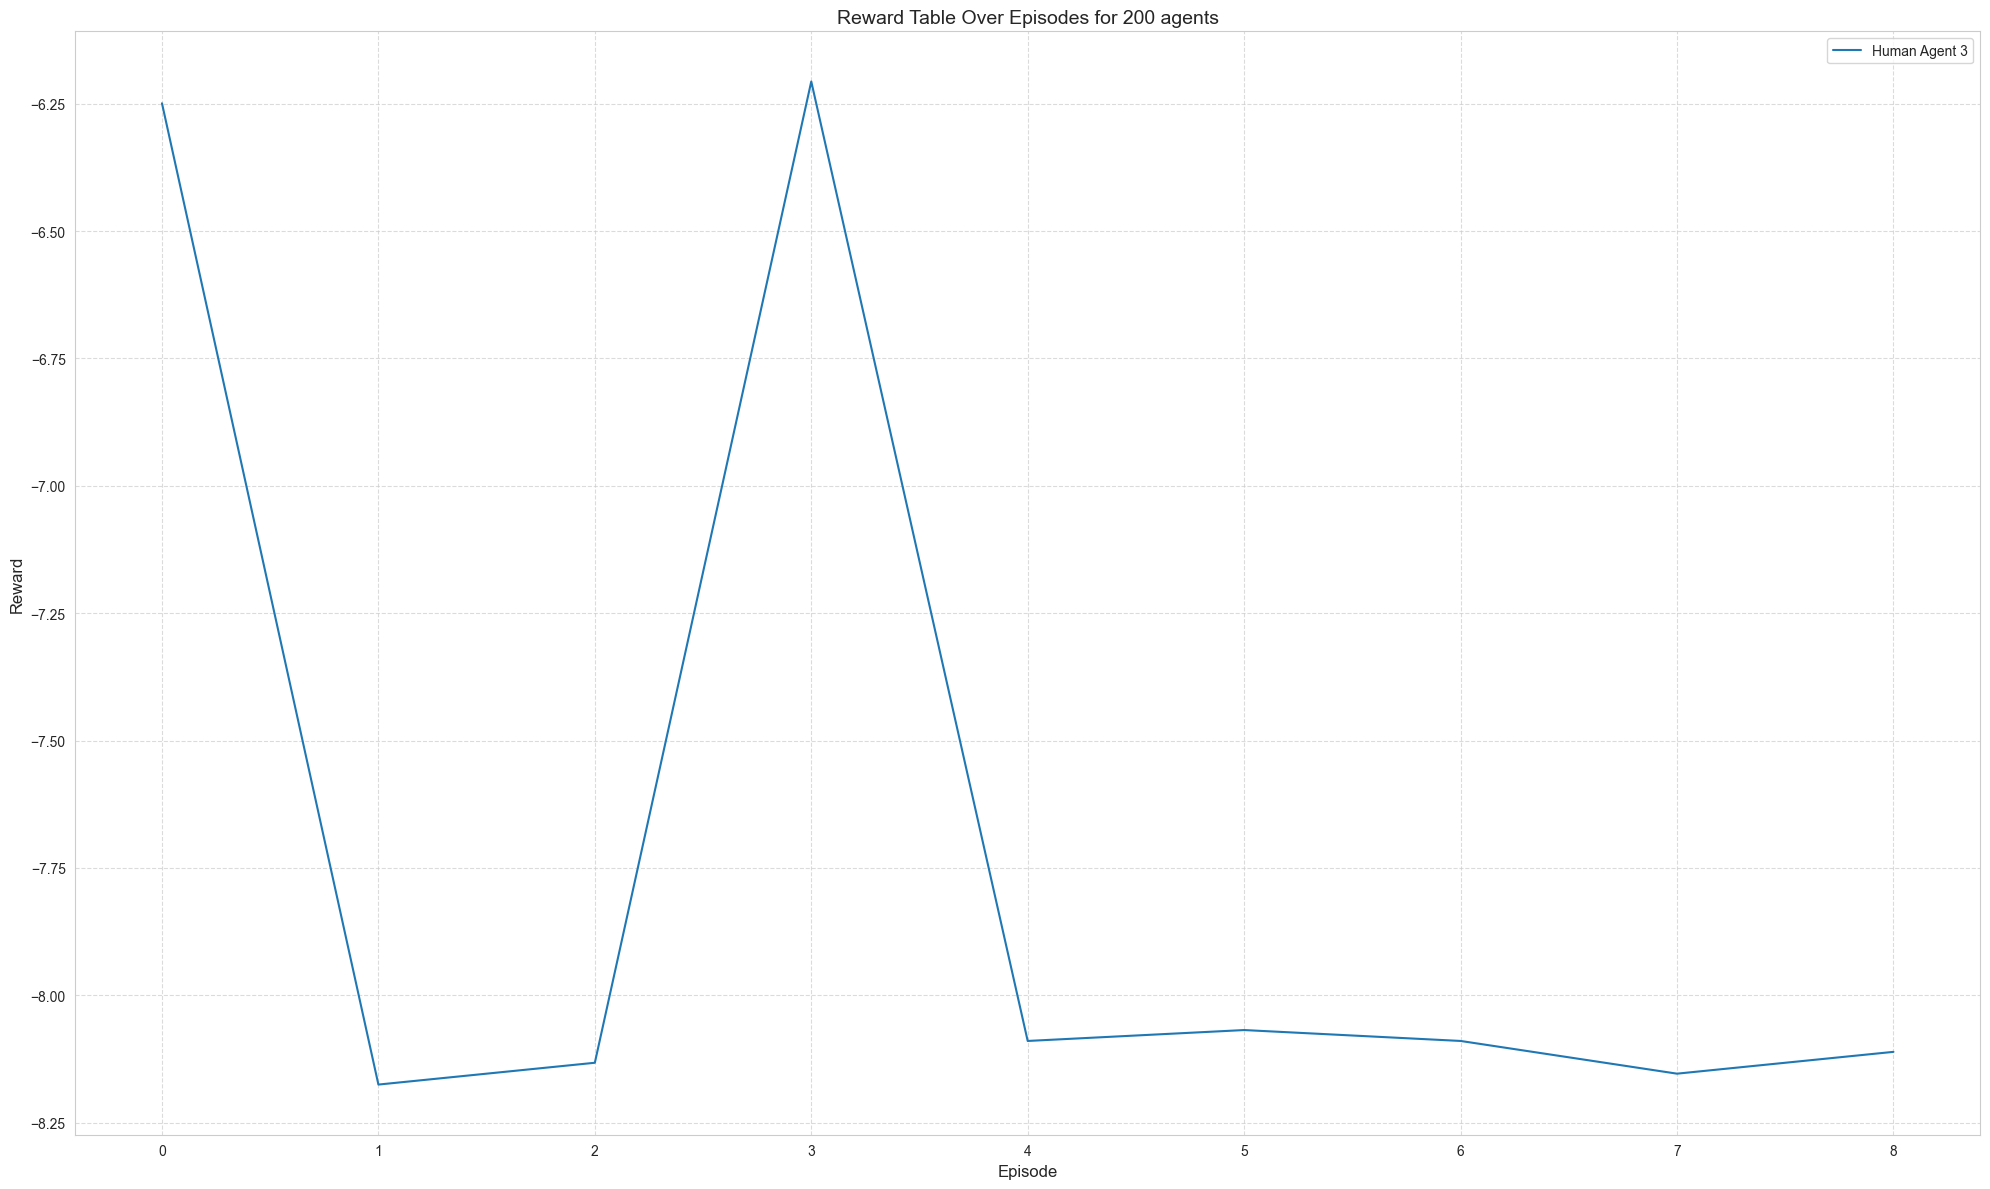

In [5]:
env.close()

In [6]:
for agent in env.human_agents:
    print("cost table is: ", agent.cost, "\n\n")

cost table is:  [1.96758703 2.08089236 2.31936458] 


cost table is:  [1.96758703 2.08089236 2.31936458] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.23342493 3.64860223 4.83388167] 


cost table is:  [1.96758703 2.08089236 2.31936458] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.96758703 2.08089236 2.31936458] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.23342493 3.64860223 4.83388167] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.23342493 3.64860223 4.83388167] 


cost table is:  [3.56797785 2.03949568 2.0852625 ] 


cost table is:  [3.56797785 2.03949568 2.0852625 ] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [1.11846739 1.67278912 0.77877151] 


cost table is:  [3.56797785 

In [7]:
env.mutation()

INFO:root:Mutation is about to happen!

INFO:root:There were 200 human agents.

INFO:root:Now there are 199 human agents.

INFO:root:Machine's observation space is: {'1': Box(0.0, 200.0, (3,), float32)} 
INFO:root:Machine's action space is: {'1': Discrete(3)}
INFO:root:Agent with id 1 has origin 1 and destination 0 and start time 361
INFO:root:Minimum travel time is: 0.7787715086034414


### Alignment of our environment with the torchrl environment

In [8]:
env = PettingZooWrapper(
    env=env,
    return_state=True,
    use_mask=True,
    group_map=None, # Use default for parallel
    categorical_actions=True,
)

INFO:root:RESET
INFO:root:New sumo label: 6410


In [9]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("1", "episode_reward")]),
)

In [10]:
check_env_specs(env)

INFO:root:RESET
INFO:root:New sumo label: 8611


INFO:root:STEP
INFO:root:New sumo label: 2671
INFO:root:Machines are about to learn!
2024-04-26 15:05:36,942 [torchrl][INFO] check_env_specs succeeded!


INFO:root:RESET
INFO:root:New sumo label: 9764
INFO:root:STEP
INFO:root:New sumo label: 6280
INFO:root:Machines are about to learn!
INFO:root:CLOSE


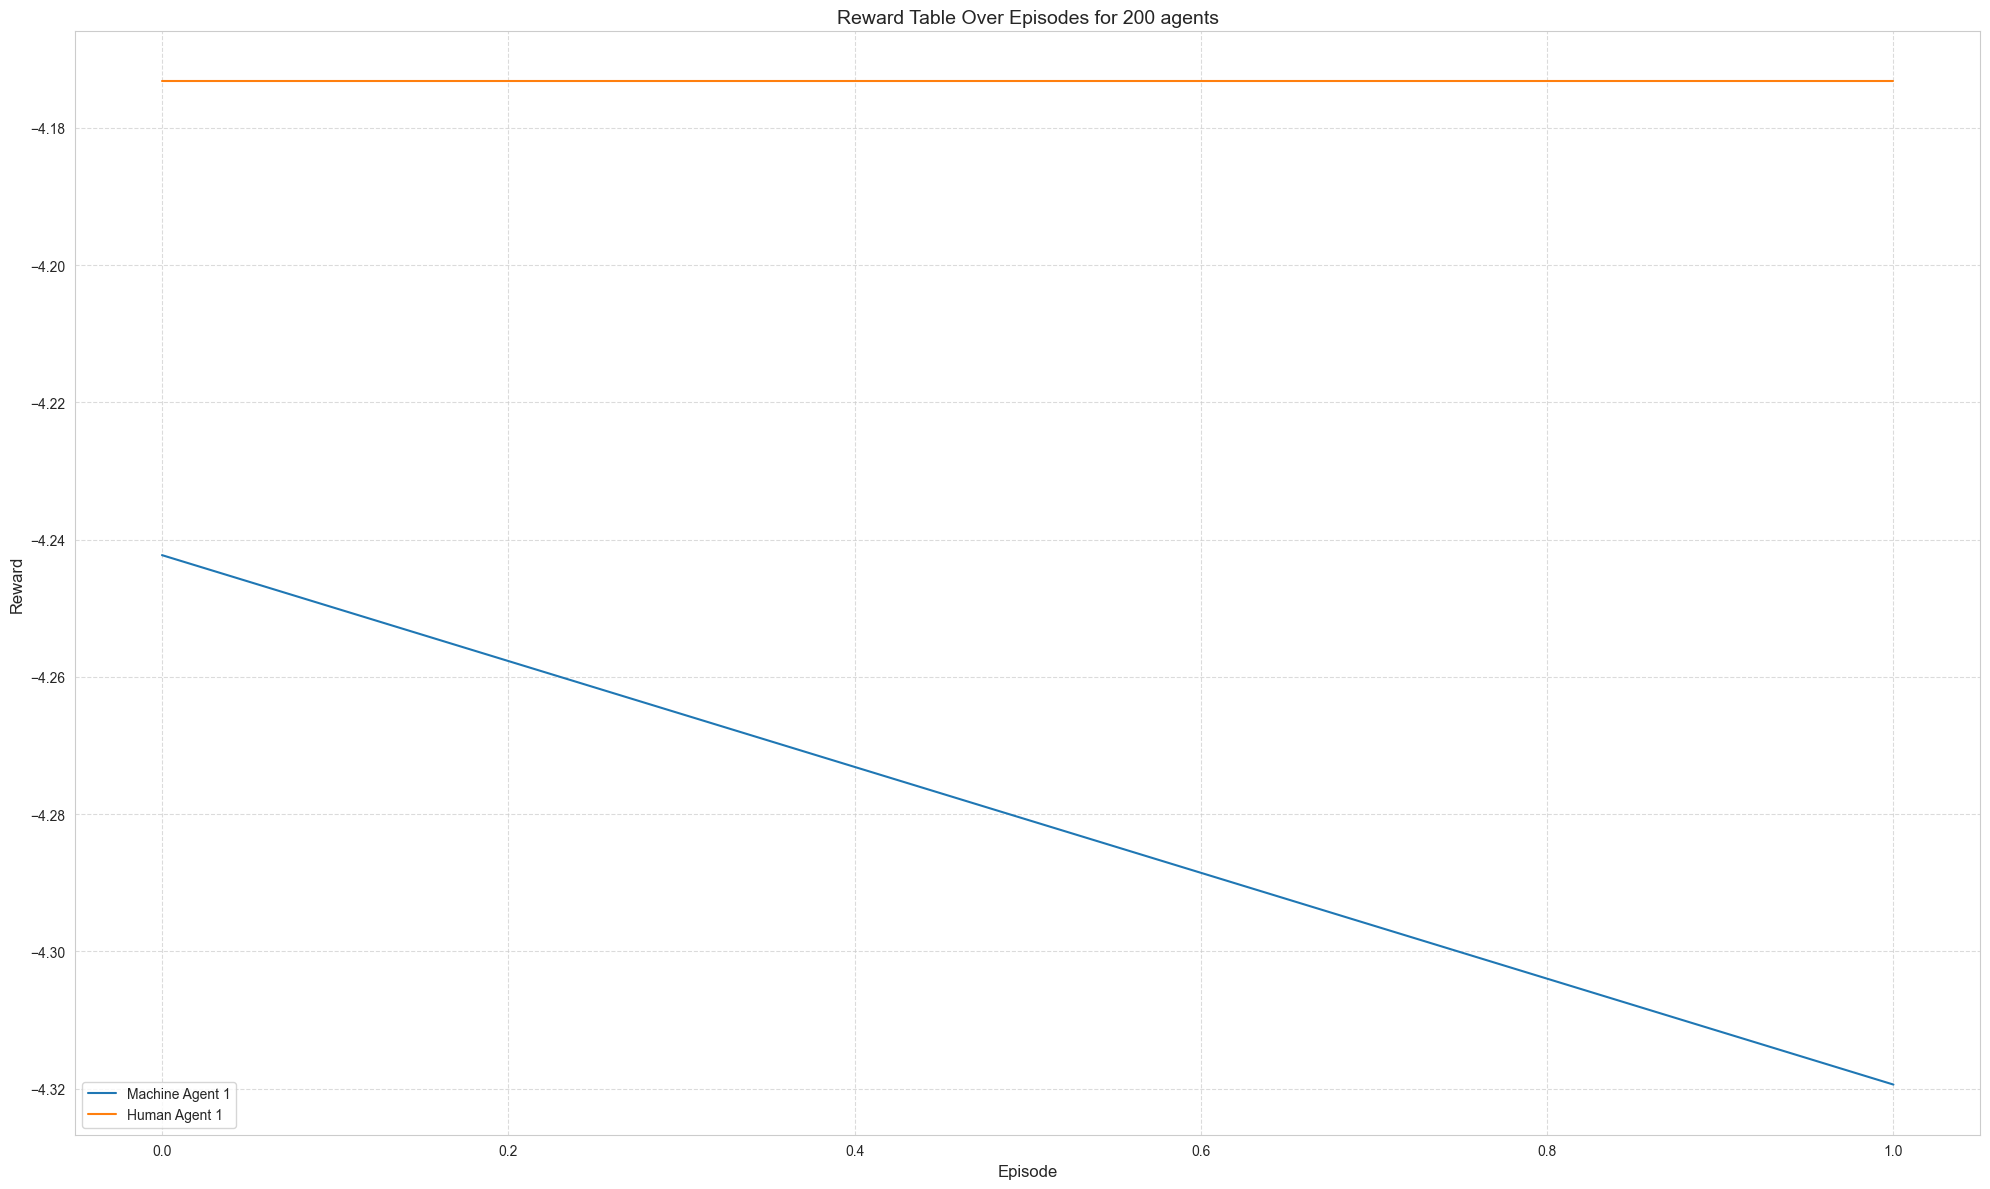

In [11]:
par_env = ParallelEnv(5, EnvCreator(lambda : env))

In [12]:
rollout = par_env.rollout(10)

In [13]:
print("action_spec:", par_env.full_action_spec)
print("reward_spec:", par_env.full_reward_spec)
print("done_spec:", par_env.full_done_spec)
print("observation_spec:", par_env.observation_spec)

action_spec: CompositeSpec(
    1: CompositeSpec(
        action: DiscreteTensorSpec(
            shape=torch.Size([5, 1]),
            space=DiscreteBox(n=3),
            device=cpu,
            dtype=torch.int64,
            domain=discrete), device=cpu, shape=torch.Size([5, 1])), device=cpu, shape=torch.Size([5]))
reward_spec: CompositeSpec(
    1: CompositeSpec(
        reward: UnboundedContinuousTensorSpec(
            shape=torch.Size([5, 1, 1]),
            space=None,
            device=cpu,
            dtype=torch.float32,
            domain=continuous), device=cpu, shape=torch.Size([5, 1])), device=cpu, shape=torch.Size([5]))
done_spec: CompositeSpec(
    done: DiscreteTensorSpec(
        shape=torch.Size([5, 1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    terminated: DiscreteTensorSpec(
        shape=torch.Size([5, 1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain

#### Understanding Reward and Action Specs

In the reward and action specs, the "agent" key is present. This means that entries in tensordicts belonging to those specs will be nested within an "agents" tensor dictionary. This grouping organizes all per-agent values.

By accessing the keys for each of these values in tensor dictionaries, we gain insight into which values are per-agent and which ones are shared. This understanding helps us effectively navigate and interpret the reward and action specifications within the environment.


In [14]:
print("action_keys:", par_env.action_keys)
print("reward_keys:", par_env.reward_keys)
print("done_keys:", par_env.done_keys)

action_keys: [('1', 'action')]
reward_keys: [('1', 'reward')]
done_keys: ['done', 'terminated', 'truncated', ('1', 'done'), ('1', 'terminated'), ('1', 'truncated')]


### Creation of the actor/policy neural network

In [15]:
share_parameters_policy = True

policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=par_env.observation_spec["1", "observation"][0].shape[-1],  # n_obs_per_agent
        n_agent_outputs=par_env.action_spec[0].shape[-1],  # 2 * n_actions_per_agents
        n_agents=par_env.n_agents()[0],
        centralised=False,  # the policies are decentralised (ie each agent will act from its observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=64,
        activation_class=torch.nn.Tanh,
    )#,
    #NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

In [16]:
policy_net

Sequential(
  (0): MultiAgentMLP(
    (agent_networks): ModuleList(
      (0): MLP(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): Tanh()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): Tanh()
        (4): Linear(in_features=64, out_features=1, bias=True)
      )
    )
  )
)

In [17]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "logits")],
)

In [18]:
policy = ProbabilisticActor(
    module=policy_module,
    spec=par_env.action_spec[0],
    in_keys=[("1", "logits")], ##
    out_keys=[par_env.action_key],
    distribution_class=Categorical,
    return_log_prob=True,
    log_prob_key=("1", "sample_log_prob"),
)  # we'll need the log-prob for the PPO loss

In [19]:
print("Running policy:", policy(par_env.reset()[0]))

Running policy: TensorDict(
    fields={
        1: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.int64, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                logits: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                sample_log_prob: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Siz

### Creation of the critic neural network

In [20]:
share_parameters_critic = True
mappo = True  # IPPO if False

critic_net = MultiAgentMLP(
    n_agent_inputs=par_env.observation_spec["1", "observation"][0].shape[-1],
    n_agent_outputs=1,  # 1 value per agent
    n_agents=par_env.n_agents()[0],
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=64,
    activation_class=torch.nn.Tanh,
)

critic = TensorDictModule(
    module=critic_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "state_value")],
)

In [21]:
print("Running value:", critic(par_env.reset()[0]))

Running value: TensorDict(
    fields={
        1: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                state_value: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dty

### Collector

> At every learning iteration we have a sampling and a training phase. In the sampling phase of iteration t, rollouts are collected from agent's interactions in the environment using the currect policies π_{t}. So, in the training phase the same policy is used to take the different samples.

![](images/On-policy-rollouts.png)

#### Understanding Training Parameters

- `n_iters`: This variable determines the number of iterations for the training loop. In other words, it specifies how many times the policy will be updated during training.

- `frames_per_batch`: This parameter indicates the amount of data that will be sampled using the current policy before updating the model. It represents the number of frames or observations collected from the environment within each training batch. These frames serve as the basis for learning in the model.


In [22]:
collector = MultiSyncDataCollector(
    [par_env],
    policy,
    device=device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    reset_at_each_iter=False,
    total_frames=total_frames,
)

### Replay Buffer

In [23]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),  # We store the frames_per_batch collected at each iteration
    sampler=SamplerWithoutReplacement(),
    batch_size=minibatch_size,  # We will sample minibatches of this size
)

### PPO loss function

In [24]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coef=entropy_eps,
    normalize_advantage=False,  # Important to avoid normalizing across the agent dimension
)
loss_module.set_keys(  # We have to tell the loss where to find the keys
    reward=par_env.reward_key,
    action=par_env.action_key,
    sample_log_prob=("1", "sample_log_prob"),
    value=("1", "state_value"),
    # These last 2 keys will be expanded to match the reward shape
    done=("1", "done"),
    terminated=("1", "terminated"),
)


loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)  # We build GAE
GAE = loss_module.value_estimator

optim = torch.optim.Adam(loss_module.parameters(), lr)

In [25]:
writer = SummaryWriter('/runs')

### Training Loop Overview

We query tensordict data from our collector object. The data collector serves as an intermediary between the policy and the environment.

- The data collector iterates the policy within the environment, executing steps in the environment, computing actions based on the policy's output, and repeating this process iteratively.

- It consolidates the collected data and presents it to us as a tensor dictionary. This tensor dictionary is structured in a way that is meaningful and relevant for our specific use case.

The inside of the loop involves the processing of the data we gathered from the collector. This process entails:

- Subsetting the collected data.
- Running the environment for a specified number of days (e.g., 6 days).
- Training the policy based on the information collected from the environment.

In essence, during the training loop, we simulate the environment for a certain duration(6 days in our case - using the same policy) and then use the collected data to train the policy. This process represents the learning phase for the agents, depicted as the "Sampling" part of the graph.


In [26]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    tensordict_data.set(
        ("next", "1", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", par_env.reward_key))),
    )
    tensordict_data.set(
        ("next", "1", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", par_env.reward_key))),
    )
    # We need to expand the done and terminated to match the reward shape (this is expected by the value estimator)

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )  # Compute GAE and add it to the data

    data_view = tensordict_data.reshape(-1)  # Flatten the batch size to shuffle data
    replay_buffer.extend(data_view)

    print("[INFO] Before the learning loop")
    for epoch in range(num_epochs):
        for _ in range(frames_per_batch // minibatch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()

            torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )  # Optional

            optim.step()
            optim.zero_grad()
            print("Loss/train", loss_value, epoch)
            writer.add_scalar("Loss/train", loss_value, global_step=epoch)

    collector.update_policy_weights_()

    # Logging
    done = tensordict_data.get(("next", "1", "done"))
    episode_reward_mean = (
        tensordict_data.get(("next", "1", "episode_reward"))[done].mean().item()
    )
    episode_reward_mean_list.append(episode_reward_mean)
    pbar.set_description(f"episode_reward_mean = {episode_reward_mean}", refresh=False)
    pbar.update()

episode_reward_mean = 0:   0%|          | 0/32 [00:00<?, ?it/s]

[INFO] Before the learning loop
Loss/train tensor(8.1894, grad_fn=<AddBackward0>) 0
Loss/train tensor(8.1541, grad_fn=<AddBackward0>) 0
Loss/train tensor(8.0451, grad_fn=<AddBackward0>) 1
Loss/train tensor(7.9974, grad_fn=<AddBackward0>) 1
Loss/train tensor(7.9176, grad_fn=<AddBackward0>) 2
Loss/train tensor(7.8207, grad_fn=<AddBackward0>) 2
Loss/train tensor(7.7807, grad_fn=<AddBackward0>) 3
Loss/train tensor(7.6494, grad_fn=<AddBackward0>) 3
Loss/train tensor(7.6302, grad_fn=<AddBackward0>) 4
Loss/train tensor(7.4862, grad_fn=<AddBackward0>) 4
Loss/train tensor(7.4667, grad_fn=<AddBackward0>) 5
Loss/train tensor(7.3299, grad_fn=<AddBackward0>) 5
Loss/train tensor(7.3160, grad_fn=<AddBackward0>) 6
Loss/train tensor(7.1540, grad_fn=<AddBackward0>) 6
Loss/train tensor(7.0944, grad_fn=<AddBackward0>) 7
Loss/train tensor(7.0422, grad_fn=<AddBackward0>) 7
Loss/train tensor(6.9757, grad_fn=<AddBackward0>) 8
Loss/train tensor(6.8202, grad_fn=<AddBackward0>) 8
Loss/train tensor(6.7675, grad_f

episode_reward_mean = -4.445414066314697:   3%|▎         | 1/32 [00:52<26:55, 52.11s/it]

Loss/train tensor(6.5947, grad_fn=<AddBackward0>) 10
Loss/train tensor(6.4983, grad_fn=<AddBackward0>) 10
Loss/train tensor(6.4137, grad_fn=<AddBackward0>) 11
Loss/train tensor(6.3177, grad_fn=<AddBackward0>) 11
Loss/train tensor(6.2362, grad_fn=<AddBackward0>) 12
Loss/train tensor(6.1272, grad_fn=<AddBackward0>) 12
Loss/train tensor(6.0069, grad_fn=<AddBackward0>) 13
Loss/train tensor(5.9828, grad_fn=<AddBackward0>) 13
Loss/train tensor(5.8086, grad_fn=<AddBackward0>) 14
Loss/train tensor(5.8019, grad_fn=<AddBackward0>) 14
Loss/train tensor(5.5981, grad_fn=<AddBackward0>) 15
Loss/train tensor(5.6284, grad_fn=<AddBackward0>) 15
[INFO] Before the learning loop
Loss/train tensor(2.7607, grad_fn=<AddBackward0>) 0
Loss/train tensor(2.6081, grad_fn=<AddBackward0>) 0
Loss/train tensor(2.5567, grad_fn=<AddBackward0>) 1
Loss/train tensor(2.4204, grad_fn=<AddBackward0>) 1
Loss/train tensor(2.3174, grad_fn=<AddBackward0>) 2
Loss/train tensor(2.2650, grad_fn=<AddBackward0>) 2
Loss/train tensor(2.

episode_reward_mean = -4.451021671295166:   6%|▋         | 2/32 [01:42<25:28, 50.96s/it]

...

Loss/train tensor(0.0518, grad_fn=<AddBackward0>) 12
Loss/train tensor(0.0136, grad_fn=<AddBackward0>) 12
Loss/train tensor(0.0395, grad_fn=<AddBackward0>) 13
Loss/train tensor(0.0259, grad_fn=<AddBackward0>) 13
Loss/train tensor(0.0502, grad_fn=<AddBackward0>) 14
Loss/train tensor(0.0152, grad_fn=<AddBackward0>) 14
Loss/train tensor(0.0274, grad_fn=<AddBackward0>) 15
Loss/train tensor(0.0380, grad_fn=<AddBackward0>) 15
[INFO] Before the learning loop
Loss/train tensor(-0.0135, grad_fn=<AddBackward0>) 0
Loss/train tensor(-0.0061, grad_fn=<AddBackward0>) 0
Loss/train tensor(-0.0032, grad_fn=<AddBackward0>) 1
Loss/train tensor(-0.0165, grad_fn=<AddBackward0>) 1
Loss/train tensor(-0.0171, grad_fn=<AddBackward0>) 2
Loss/train tensor(-0.0025, grad_fn=<AddBackward0>) 2
Loss/train tensor(-0.0196, grad_fn=<AddBackward0>) 3
Loss/train tensor(7.1623e-05, grad_fn=<AddBackward0>) 3
Loss/train tensor(0.0011, grad_fn=<AddBackward0>) 4
Loss/train tensor(-0.0207, grad_fn=<AddBackward0>) 4
Loss/train t

episode_reward_mean = -4.436018466949463:  72%|███████▏  | 23/32 [18:28<06:17, 41.97s/it]

Loss/train tensor(-0.0044, grad_fn=<AddBackward0>) 7
Loss/train tensor(-0.0112, grad_fn=<AddBackward0>) 8
Loss/train tensor(-0.0085, grad_fn=<AddBackward0>) 8
Loss/train tensor(-0.0107, grad_fn=<AddBackward0>) 9
Loss/train tensor(-0.0089, grad_fn=<AddBackward0>) 9
Loss/train tensor(-0.0017, grad_fn=<AddBackward0>) 10
Loss/train tensor(-0.0179, grad_fn=<AddBackward0>) 10
Loss/train tensor(-0.0127, grad_fn=<AddBackward0>) 11
Loss/train tensor(-0.0069, grad_fn=<AddBackward0>) 11
Loss/train tensor(0.0163, grad_fn=<AddBackward0>) 12
Loss/train tensor(-0.0358, grad_fn=<AddBackward0>) 12
Loss/train tensor(-0.0172, grad_fn=<AddBackward0>) 13
Loss/train tensor(-0.0024, grad_fn=<AddBackward0>) 13
Loss/train tensor(-0.0042, grad_fn=<AddBackward0>) 14
Loss/train tensor(-0.0154, grad_fn=<AddBackward0>) 14
Loss/train tensor(-0.0266, grad_fn=<AddBackward0>) 15
Loss/train tensor(0.0070, grad_fn=<AddBackward0>) 15
[INFO] Before the learning loop
Loss/train tensor(0.0016, grad_fn=<AddBackward0>) 0
Loss/

episode_reward_mean = -4.433870315551758:  75%|███████▌  | 24/32 [19:13<05:43, 42.90s/it]

tensor(0.0118, grad_fn=<AddBackward0>) 8
Loss/train tensor(-0.0183, grad_fn=<AddBackward0>) 8
Loss/train tensor(-0.0090, grad_fn=<AddBackward0>) 9
Loss/train tensor(0.0025, grad_fn=<AddBackward0>) 9
Loss/train tensor(-0.0171, grad_fn=<AddBackward0>) 10
Loss/train tensor(0.0106, grad_fn=<AddBackward0>) 10
Loss/train tensor(-0.0169, grad_fn=<AddBackward0>) 11
Loss/train tensor(0.0104, grad_fn=<AddBackward0>) 11
Loss/train tensor(-0.0170, grad_fn=<AddBackward0>) 12
Loss/train tensor(0.0104, grad_fn=<AddBackward0>) 12
Loss/train tensor(0.0022, grad_fn=<AddBackward0>) 13
Loss/train tensor(-0.0086, grad_fn=<AddBackward0>) 13
Loss/train tensor(0.0104, grad_fn=<AddBackward0>) 14
Loss/train tensor(-0.0168, grad_fn=<AddBackward0>) 14
Loss/train tensor(-0.0027, grad_fn=<AddBackward0>) 15
Loss/train tensor(-0.0039, grad_fn=<AddBackward0>) 15


In [ ]:
writer.close()

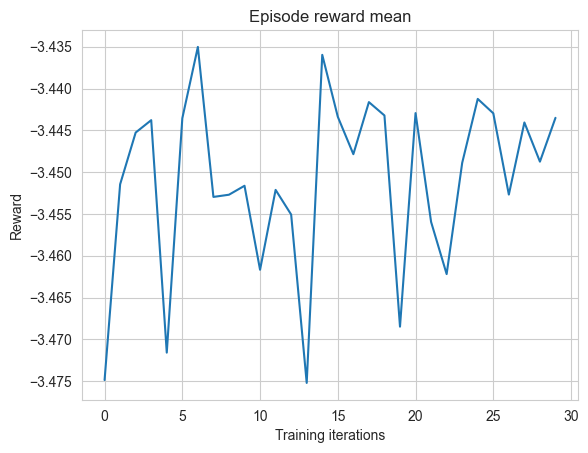

In [ ]:
plt.plot(episode_reward_mean_list)
plt.xlabel("Training iterations")
plt.ylabel("Reward")
plt.title("Episode reward mean")
plt.show()